In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
from sklearn.model_selection import GroupShuffleSplit

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = r"..\Dataset\clean_data.csv"
UNCALIB_MODEL_PATH = r"..\models\xgb_pipeline.pkl"
CALIB_MODEL_PATH = r"..\models\calibrated_xgb_pipeline.pkl"

In [3]:
df = pd.read_csv(DATA_PATH)
df.head(5)

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,2278392,8222157,Caucasian,Female,5,Not_Available,Not_Mapped,Physician_Referral,1,41,...,No,No,No,No,No,No,No,No,No,0
1,64410,86047875,AfricanAmerican,Female,25,Emergency,Discharged_Home,Emergency_Room,2,11,...,No,No,No,No,No,No,No,No,Yes,0
2,500364,82442376,Caucasian,Male,35,Emergency,Discharged_Home,Emergency_Room,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,0
3,16680,42519267,Caucasian,Male,45,Emergency,Discharged_Home,Emergency_Room,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,0
4,55842,84259809,Caucasian,Male,65,Elective,Discharged_Home,Clinic_Referral,4,70,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [4]:
X = df.drop(columns=['target', 'encounter_id'])
y = df['target']
groups = df['patient_nbr']

# 2. Get the Test Set
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
_, test_idx = next(gss.split(X, y, groups=groups))

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

In [5]:
# Load both pipelines
uncalib_pipeline = joblib.load(UNCALIB_MODEL_PATH)
calib_pipeline = joblib.load(CALIB_MODEL_PATH)

# Extract pieces from the UNCALIBRATED pipeline for SHAP
preprocessor = uncalib_pipeline.named_steps['preprocessor']
xgb_model = uncalib_pipeline.named_steps['classifier']

# Transform the test data (SHAP needs the numerical/one-hot encoded data, not raw text)
X_test_transformed = preprocessor.transform(X_test)

# Get the exact feature names created by the OneHotEncoder
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][1].get_feature_names_out(preprocessor.transformers_[1][2])
all_feature_names = list(num_features) + list(cat_features)

print(f"Extracted {len(all_feature_names)} features for SHAP Explainer.")

Extracted 162 features for SHAP Explainer.


--- GLOBAL: TOP 20 RISK DRIVERS ---


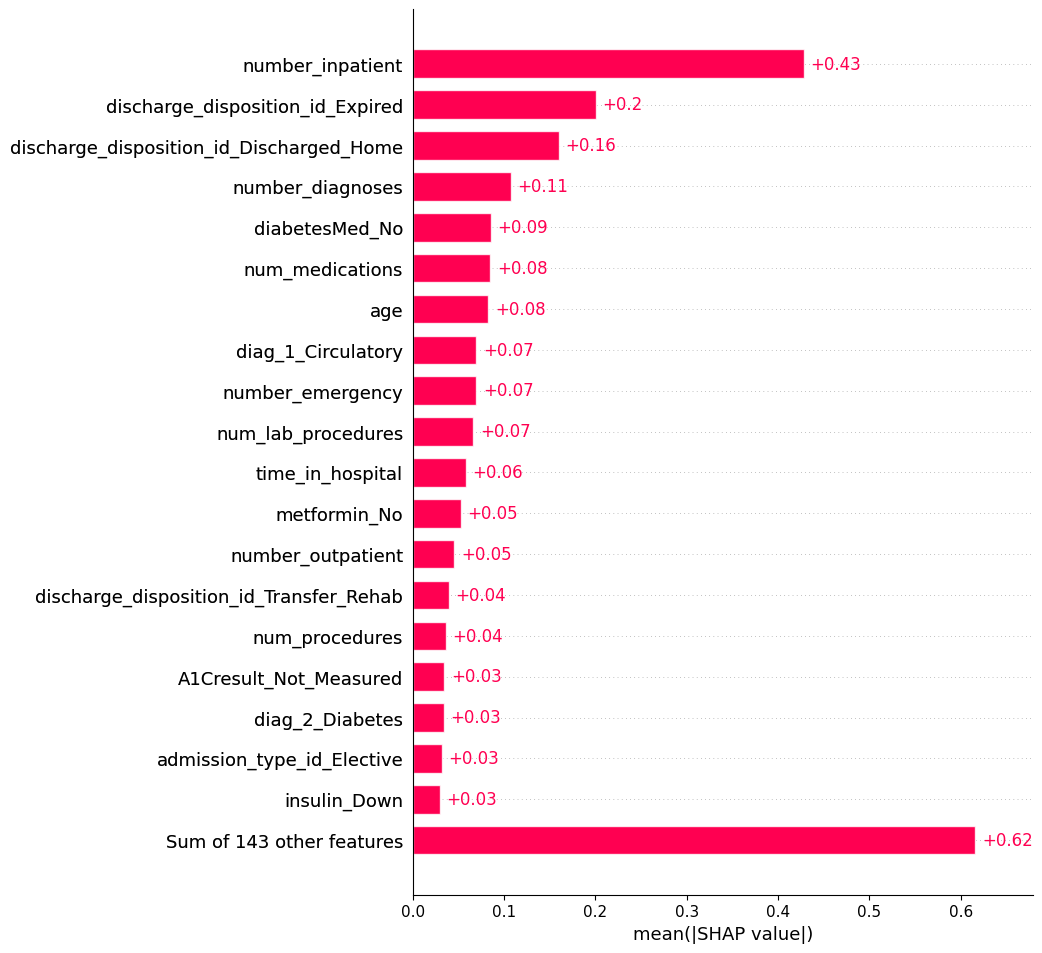

--- GLOBAL: DIRECTIONAL IMPACT ---


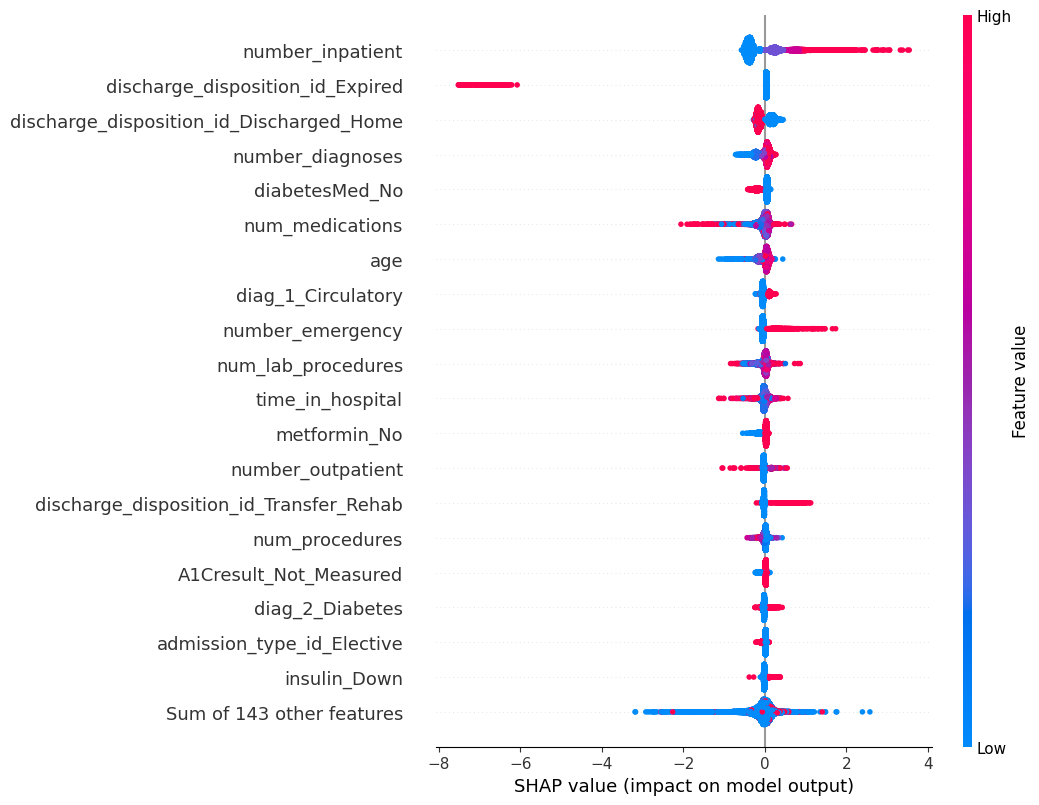

In [6]:
# Initialize TreeExplainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_transformed)
shap_values.feature_names = all_feature_names

print("--- GLOBAL: TOP 20 RISK DRIVERS ---")
# Bar plot shows absolute impact magnitude
shap.plots.bar(shap_values, max_display=20)

print("--- GLOBAL: DIRECTIONAL IMPACT ---")
# Beeswarm plot shows if a feature *increases* (red) or *decreases* (blue) risk
shap.plots.beeswarm(shap_values, max_display=20)

In [7]:
def explain_single_patient(patient_index_in_test_set):
    # Get raw patient data
    raw_patient = X_test.iloc[[patient_index_in_test_set]]

    # 1. Get the highly accurate, CALIBRATED risk score
    risk_score = calib_pipeline.predict_proba(raw_patient)[0, 1]

    # 2. Get the SHAP values using the uncalibrated model
    transformed_patient = preprocessor.transform(raw_patient)
    sv = explainer(transformed_patient)
    sv.feature_names = all_feature_names

    # Render the visual waterfall plot
    print(f"PATIENT {patient_index_in_test_set} - TRUE READMISSION: {y_test.iloc[patient_index_in_test_set]}")
    print(f"CALIBRATED RISK SCORE: {risk_score * 100:.1f}%\n")
    shap.plots.waterfall(sv[0], max_display=10)

    # 3. Build the JSON payload for the API
    feature_impacts = pd.DataFrame({
        'feature': all_feature_names,
        'shap_value': sv[0].values
    })

    # Sort by absolute impact to get the top drivers
    feature_impacts['abs_impact'] = feature_impacts['shap_value'].abs()
    top_drivers = feature_impacts.sort_values('abs_impact', ascending=False).head(3)

    api_payload = {
        "risk_score": float(round(risk_score, 3)),
        "top_drivers": []
    }

    for _, row in top_drivers.iterrows():
        direction = "increases risk" if row['shap_value'] > 0 else "decreases risk"
        api_payload["top_drivers"].append({
            "feature": row['feature'],
            "shap_impact": float(round(row['shap_value'], 3)),
            "direction": direction
        })

    return api_payload

PATIENT 0 - TRUE READMISSION: 0
CALIBRATED RISK SCORE: 6.6%



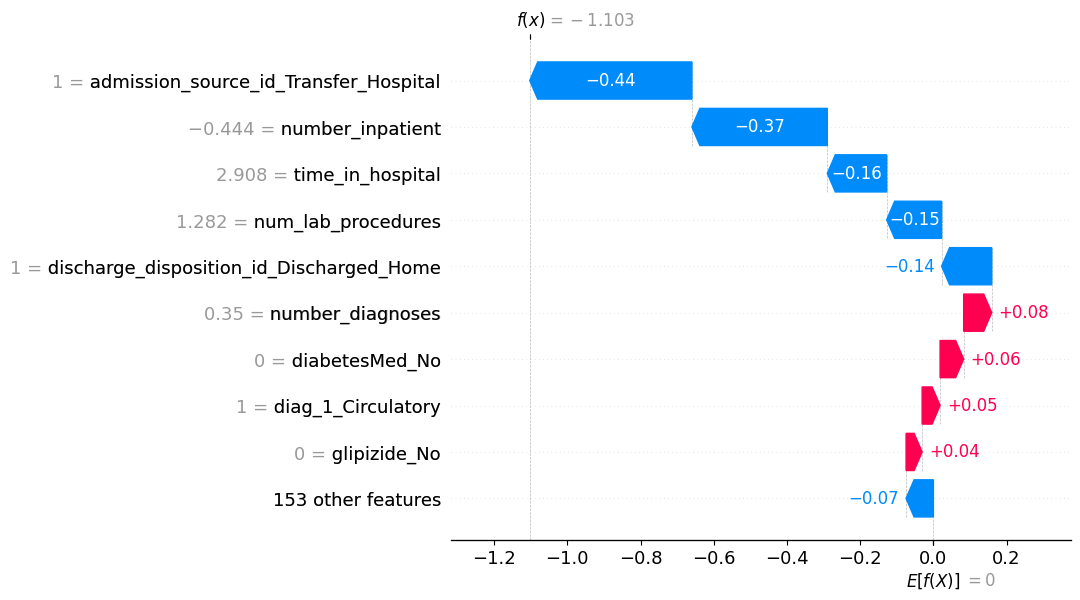


--- JSON OUTPUT FOR THE API (Phase 6) ---
{
    "risk_score": 0.066,
    "top_drivers": [
        {
            "feature": "admission_source_id_Transfer_Hospital",
            "shap_impact": -0.443,
            "direction": "decreases risk"
        },
        {
            "feature": "number_inpatient",
            "shap_impact": -0.37,
            "direction": "decreases risk"
        },
        {
            "feature": "time_in_hospital",
            "shap_impact": -0.162,
            "direction": "decreases risk"
        }
    ]
}


In [8]:
# Test the function on Patient #0
json_payload = explain_single_patient(0)
print("\n--- JSON OUTPUT FOR THE API (Phase 6) ---")
import json
print(json.dumps(json_payload, indent=4))